In [4]:
# =============================================================================
# COMP20008 Assignment 2 Stage 1 preprocessing
# Group W08G02
# Research question: To what extent can Superhost status among Melbourne
# Airbnb listings be predicted from listing attributes, review performance
# and host activity, and do the features that drive that prediction reflect
# guest facing quality or the host operating profile.
# Analysis file. listings.csv.gz, the detailed Inside Airbnb Melbourne table.
# The compact listings.csv file is not used for modelling because it does not
# contain host_is_superhost, review scores, amenities or property_type.
# =============================================================================

import json
import numpy as np
import pandas as pd

LISTINGS_PATH = "listings.csv.gz"
SCRAPE_FALLBACK = pd.Timestamp("2026-06-17")

raw = pd.read_csv(LISTINGS_PATH, compression="gzip", low_memory=False)

print("Loaded shape", raw.shape)
print("last_scraped distribution")
print(raw["last_scraped"].value_counts())

# The Superhost badge is stored as t or f on every listing row. There are
# 25728 listings and 14113 hosts in this scrape. A separate host level check
# found zero hosts with mixed Superhost labels across their listings, so the
# listing row is a valid place to read the badge. The raw class split is
# 7885 Superhost rows which is 30.65 percent and 17843 non Superhost rows
# which is 69.35 percent. These two counts are frozen now. Later sections
# must reuse them unless a filter is declared and the new counts are restated.
assert raw["host_is_superhost"].isna().sum() == 0
raw["is_superhost"] = (raw["host_is_superhost"] == "t").astype(int)

n0 = len(raw)
n_sh0 = int(raw["is_superhost"].sum())
rate0 = raw["is_superhost"].mean()
print(f"BASELINE N={n0} Superhost={n_sh0} rate={rate0:.6f}")

df = raw.copy()

# -----------------------------------------------------------------------------
# Supporting parses reused from Assignment 1
# These two conversions are not counted as one of the three required
# preprocessing tasks. They only make existing columns numeric so later
# correlation and models can use them if the group chooses to.
# -----------------------------------------------------------------------------

def parse_bathrooms_text(val):
    """Return the leading number from bathrooms_text.

    The numeric bathrooms column is missing on 8164 of 25728 rows which is
    31.71 percent. The bathrooms_text column is missing on only 26 rows which
    is 0.10 percent. Parsing the text therefore recovers a size feature that
    would otherwise be unusable. Strings such as 1 bath and 1.5 shared baths
    start with a number. half bath is treated as 0.5.
    """
    if pd.isna(val):
        return np.nan
    token = str(val).strip().split(" ")[0]
    if token.lower() in {"half-bath", "half"}:
        return 0.5
    try:
        return float(token)
    except ValueError:
        return np.nan

df["bathrooms_num"] = df["bathrooms_text"].apply(parse_bathrooms_text)

def parse_price(val):
    """Strip the currency symbol and thousands separators from price.

    Price is missing on 25.47 percent of rows. The research question does not
    treat price as a core quality signal or a core operating signal, so we
    parse it for optional use and we do not impute it. Imputing a quarter of
    the column would invent a market price and then leak that invention into
    correlation and feature selection.
    """
    if pd.isna(val):
        return np.nan
    return pd.to_numeric(str(val).replace("$", "").replace(",", ""), errors="coerce")

df["price_num"] = df["price"].apply(parse_price)

# =============================================================================
# Six candidate preprocessing tasks
# The specification asks the group to name at least six distinct candidates
# and to implement three of them. Each implemented task must be justified
# with a number computed from this dataset and with a reason that points
# back to the research question. Generic claims such as missing values can
# bias a model score zero. The six candidates and the three decisions are
# written here so the Methods section can quote them without rewriting.
#
# Candidate 1. Review recency and a no review flag. IMPLEMENTED.
# last_review is missing on exactly 4477 rows. Those 4477 rows are the same
# rows that have number_of_reviews equal to zero and review_scores_rating
# equal to missing. That is 17.40 percent of the table. 295 of those 4477
# rows still carry a Superhost badge. Recency is a guest facing quality
# feature. Deleting the 4477 rows would raise the Superhost rate from
# 30.65 percent to 35.72 percent and would remove the listings that are
# hardest to classify. The implemented choice is therefore to keep every
# row, store days since last review where it exists, and store a binary
# has_reviews flag so the missingness itself remains a feature.
#
# Candidate 2. Multi listing operating flag. IMPLEMENTED.
# Two host scale columns exist. host_listings_count can include listings
# the host operates outside Melbourne. calculated_host_listings_count is
# the count of listings that appear in this Melbourne scrape. The two
# columns disagree on 7395 of 25728 rows which is 28.74 percent. Neither
# column is missing. Superhost rate is 23.74 percent on the 11383 single
# listing rows and 36.13 percent on the 14345 multi listing rows. That
# gap is the operating profile contrast the second half of the research
# question asks the group to test. The implemented choice is a binary
# flag from calculated_host_listings_count at the threshold of two, while
# the integer count is kept for correlation.
#
# Candidate 3. Property type consolidation. IMPLEMENTED.
# property_type has 82 distinct values. 41 of those 82 values appear on
# fewer than 10 listings. A one hot encoding of 82 levels would give KNN
# a sparse dummy space dominated by rare columns. room_type has only four
# levels but it hides professional inventory. There are 52 rows labelled
# Hotel room under room_type and 202 rows labelled Room in hotel under
# property_type. Collapsing to room_type would treat hotel operations as
# if they were ordinary private rooms. The implemented choice is five
# groups that keep hotel and serviced stock visible and that fold the
# rare unique stays into one group instead of 41 tiny dummies.
#
# Candidate 4. Distance to the CBD in kilometres then distance bands.
# REJECTED. Superhost is a host badge. One host can hold listings in the
# CBD and in an outer suburb and the badge is the same on every row.
# A distance feature would answer a location and price question. It would
# not help the group decide whether guest facing quality or the host
# operating profile drives the badge.
#
# Candidate 5. Minimum stay buckets of short, medium and long.
# REJECTED. minimum_nights is missing on only 9 rows. The median is 2.
# Only 1.66 percent of listings ask for 30 nights or more. Building a
# long stay bucket would create a rare class that does not move Superhost
# status in this scrape and would spend page space on a feature the
# research question does not need.
#
# Candidate 6. Bedrooms and beds imputed inside each room_type.
# REJECTED even though the missingness pattern is strong. bedrooms is
# missing on 18.19 percent of all rows, but the rate is 2.47 percent for
# Entire home or apartment, 61.28 percent for Private room (4054 of 6616)
# and 66.67 percent for Shared room. An imputation rule by room type
# would be technically defensible. It is still the wrong task for this
# research question because listing size is not the quality versus
# operations contrast being tested, and room_type itself is already kept
# as a predictor.
# =============================================================================

# -----------------------------------------------------------------------------
# Implemented task 1 of 3
# Engineer days_since_last_review and has_reviews
# Alternative that was considered and rejected
# Drop every row whose last_review is missing.
# That alternative deletes 4477 rows and 295 Superhosts and silently
# changes the class balance that every later metric will be judged on.
# -----------------------------------------------------------------------------

df["last_review_dt"] = pd.to_datetime(df["last_review"], errors="coerce")
df["last_scraped_dt"] = pd.to_datetime(df["last_scraped"], errors="coerce")

# Recency must be measured against the day this row was scraped, not against
# an arbitrary calendar date. last_scraped is 2026-06-17 on 18884 rows,
# 2026-06-29 on 6173 rows, 2026-06-28 on 670 rows and 2026-07-01 on 1 row.
# Using one global date would add up to twelve extra days of recency on the
# later scrape block and would look like a data error in the report. Rows
# with a missing scrape date fall back to 2026-06-17 because that is the
# majority scrape day.
ref = df["last_scraped_dt"].fillna(SCRAPE_FALLBACK)
df["days_since_last_review"] = (ref - df["last_review_dt"]).dt.days

# A small number of rows can show a last_review after last_scraped if the
# two timestamps come from different refresh cycles. A negative recency
# would mean the guest reviewed the listing in the future. Those values
# are clipped to zero so they do not invert the quality signal.
df.loc[df["days_since_last_review"] < 0, "days_since_last_review"] = 0

df["has_reviews"] = (df["number_of_reviews"].fillna(0) > 0).astype(int)

n_no_review = int((df["has_reviews"] == 0).sum())
n_sh_no_review = int(df.loc[df["has_reviews"] == 0, "is_superhost"].sum())
recency_obs = df["days_since_last_review"].dropna()

print("STEP 1 review recency")
print(f"rows with zero reviews and missing last_review {n_no_review}")
print(f"share of the table {n_no_review / n0 * 100:.2f} percent")
print(f"Superhosts inside those rows {n_sh_no_review}")
print(
    "days_since_last_review among reviewed listings "
    f"n={recency_obs.shape[0]} "
    f"median={recency_obs.median():.0f} "
    f"p90={recency_obs.quantile(0.90):.0f} "
    f"max={recency_obs.max():.0f}"
)

# Correlation and KNN need a numeric recency on every row. Filling the
# 4477 missing recency values with the median of reviewed listings would
# pretend that a listing that has never been reviewed was reviewed as
# recently as a typical listing. That fill would shrink the very quality
# gap the research question is trying to measure. The fill used here is
# the observed maximum recency plus one day. Combined with has_reviews
# equal to zero, that code means unseen or extremely stale and it is
# reversible. Modelling cells can still restrict to has_reviews equal to
# one if the group later decides to train only on reviewed listings.
recency_fill = recency_obs.max() + 1
df["days_since_last_review_filled"] = df["days_since_last_review"].fillna(recency_fill)
print(f"missing recency filled with {recency_fill:.0f} which is observed max plus one")

rating_obs = df["review_scores_rating"].dropna()
print(
    "review_scores_rating on reviewed listings "
    f"n={len(rating_obs)} "
    f"mean={rating_obs.mean():.3f} "
    f"median={rating_obs.median():.3f}"
)

# review_scores_rating is left as missing on the 4477 zero review rows.
# The Methods section will state which of two modelling options is used.
# Option A restricts supervised learning to has_reviews equal to one and
# restates N as 21251 and the Superhost rate as 35.72 percent in every
# later section. Option B keeps all 25728 rows and carries a missing
# rating indicator. Either option is honest. Mixing them across sections
# is how consistency marks are lost.
rate_if_dropped = df.loc[df["has_reviews"] == 1, "is_superhost"].mean()
n_if_dropped = n0 - n_no_review
n_sh_if_dropped = int(df.loc[df["has_reviews"] == 1, "is_superhost"].sum())
print(
    "counterfactual if zero review rows were dropped "
    f"N={n_if_dropped} Superhost={n_sh_if_dropped} "
    f"rate={rate_if_dropped:.6f}"
)
print(f"class balance after this step is unchanged at {rate0 * 100:.2f} percent")

# -----------------------------------------------------------------------------
# Implemented task 2 of 3
# Derive is_multi_listing from calculated_host_listings_count
# Alternative that was considered and rejected
# Use host_listings_count as the scale feature, or keep only the integer
# and never build a flag. host_listings_count is not a Melbourne only
# count. The 28.74 percent disagreement with calculated_host_listings_count
# would make the operating profile story impossible to defend in viva.
# -----------------------------------------------------------------------------

assert df["calculated_host_listings_count"].isna().sum() == 0
assert df["calculated_host_listings_count"].min() >= 1

df["is_multi_listing"] = (df["calculated_host_listings_count"] >= 2).astype(int)

n_multi = int(df["is_multi_listing"].sum())
n_single = n0 - n_multi
rate_single = df.loc[df["is_multi_listing"] == 0, "is_superhost"].mean()
rate_multi = df.loc[df["is_multi_listing"] == 1, "is_superhost"].mean()
n_disagree = int(
    (df["host_listings_count"] != df["calculated_host_listings_count"]).sum()
)
disagree_rate = n_disagree / n0

print("STEP 2 multi listing operating flag")
print(
    "host_listings_count disagrees with calculated_host_listings_count on "
    f"{n_disagree} rows which is {disagree_rate * 100:.2f} percent"
)
print(
    f"single listing rows {n_single} "
    f"Superhost rate {rate_single * 100:.2f} percent"
)
print(
    f"multi listing rows {n_multi} "
    f"Superhost rate {rate_multi * 100:.2f} percent"
)
print(
    "The 12.39 percentage point gap is the operating profile split. "
    "Feature selection and clustering must be able to recover this split "
    "if the second half of the research question is true."
)

# -----------------------------------------------------------------------------
# Implemented task 3 of 3
# Collapse property_type from 82 values to five groups
# Alternative that was considered and rejected
# Keep all 82 levels, or replace property_type with room_type. 41 levels
# have fewer than 10 listings so KNN would treat rarity as distance.
# room_type would hide 202 Room in hotel rows inside a 52 row Hotel room
# class and would erase a professional operating pattern.
# -----------------------------------------------------------------------------

def consolidate_property_type(val):
    """Map the raw property_type string onto five groups.

    hotel_or_serviced captures Room in hotel, Room in aparthotel, Room in
    boutique hotel, hostels, bed and breakfast and serviced apartments.
    Those listings are run as inventory rather than as a spare room, so
    they belong in the operating profile bucket.

    shared_room and private_room keep the guest access model visible.
    Access model is a listing attribute the first half of the research
    question allows, and it is not the same thing as Superhost.

    entire_place holds ordinary whole properties, which are the majority
    class with Entire rental unit at 11262 rows and Entire home at 4512.

    other_unique holds farm stays, tiny homes, campers and the long tail
    of one off stays. Leaving them as 41 separate dummies would spend
    degrees of freedom on types that cannot support a stable Superhost
    rate. Folding them together keeps the unusual stay signal without
    breaking KNN.
    """
    if pd.isna(val):
        return "other_unique"
    s = str(val)
    sl = s.lower()

    hotel_tokens = (
        "hotel",
        "aparthotel",
        "boutique hotel",
        "hostel",
        "serviced apartment",
        "bed and breakfast",
    )
    if s.startswith("Room in") or any(tok in sl for tok in hotel_tokens):
        return "hotel_or_serviced"

    if s.startswith("Shared room"):
        return "shared_room"

    if s.startswith("Private room"):
        return "private_room"

    unique_tokens = (
        "tiny home",
        "farm stay",
        "camper",
        "rv",
        "barn",
        "dome",
        "yurt",
        "tent",
        "treehouse",
        "castle",
        "boat",
        "train",
        "bus",
        "tipi",
        "hut",
        "tower",
        "earthen",
    )
    if any(tok in sl for tok in unique_tokens):
        return "other_unique"

    if s.startswith("Entire"):
        return "entire_place"

    return "other_unique"

n_types_before = df["property_type"].nunique(dropna=False)
rare_types = int((df["property_type"].value_counts() < 10).sum())
df["property_group"] = df["property_type"].apply(consolidate_property_type)

print("STEP 3 property type consolidation")
print(f"raw property_type levels {n_types_before}")
print(f"levels with fewer than 10 listings {rare_types}")
print("grouped row counts")
print(df["property_group"].value_counts())
print("Superhost rate by group")
print(
    df.groupby("property_group")["is_superhost"]
    .mean()
    .mul(100)
    .round(2)
)

# -----------------------------------------------------------------------------
# Helper feature used later in the quality bucket
# This is not one of the three required tasks. amenity_count turns the
# amenities JSON string into a single guest facing richness score so the
# group does not have to one hot hundreds of amenity names.
# -----------------------------------------------------------------------------

def count_amenities(val):
    if pd.isna(val):
        return 0
    try:
        parsed = json.loads(val) if isinstance(val, str) else val
        return len(parsed) if isinstance(parsed, list) else 0
    except (json.JSONDecodeError, TypeError):
        return 0

df["amenity_count"] = df["amenities"].apply(count_amenities)
print(
    "amenity_count "
    f"median={df['amenity_count'].median():.0f} "
    f"mean={df['amenity_count'].mean():.1f}"
)

# -----------------------------------------------------------------------------
# Freeze the analysis table
# Row count stays at 25728. Superhost rate stays at 30.65 percent.
# If a later modelling cell filters to reviewed listings only, that cell
# must print the new N of 21251 and the new rate of 35.72 percent and the
# report must use those new figures in every following section.
# host_since is missing on every row in this scrape. Host tenure is taken
# from hosts_time_as_host_years which is complete, with a median of 5 years
# and a maximum of 15 years. That column needs no preprocessing.
# host_response_rate and host_acceptance_rate are empty on every row.
# That emptiness is a limitation, not a preprocessing task, because no
# transformation can recover a column that was not published.
# -----------------------------------------------------------------------------

keep = [
    "id",
    "host_id",
    "is_superhost",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "room_type",
    "property_type",
    "property_group",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms_num",
    "price_num",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "has_reviews",
    "days_since_last_review",
    "days_since_last_review_filled",
    "host_listings_count",
    "calculated_host_listings_count",
    "is_multi_listing",
    "availability_365",
    "hosts_time_as_host_years",
    "amenity_count",
    "last_review",
    "last_scraped",
]

missing_keep = [c for c in keep if c not in df.columns]
if missing_keep:
    raise KeyError(f"Missing expected columns: {missing_keep}")

processed = df[keep].copy()
assert len(processed) == n0
assert processed["is_superhost"].mean() == rate0

# Readable impact table. Rates as percents so the notebook does not wrap 0.306475.
impact_view = pd.DataFrame(
    {
        "step": [
            "0 baseline",
            "1 recency, all rows kept",
            "1 counterfactual drop 0 review rows",
            "2 is_multi_listing derived",
            "3 property_group derived",
        ],
        "n_rows": [n0, n0, n_if_dropped, n0, n0],
        "superhost_n": [n_sh0, n_sh0, n_sh_if_dropped, n_sh0, n_sh0],
        "superhost_pct": [
            f"{rate0 * 100:.2f}%",
            f"{rate0 * 100:.2f}%",
            f"{rate_if_dropped * 100:.2f}%",
            f"{rate0 * 100:.2f}%",
            f"{rate0 * 100:.2f}%",
        ],
        "what_changed": [
            "7885 of 25728 listings are Superhost (30.65%)",
            "4477 rows flagged has_reviews=0. 295 Superhosts retained.",
            "Rate would rise from 30.65% to 35.72%.",
            "14345 of 25728 are multi listing. Superhost 23.74% vs 36.13%.",
            "82 types including 41 rare types became 5 groups.",
        ],
    }
)
print("PREPROCESS IMPACT")
print(f"{'step':<38} {'n_rows':>8} {'superhost_n':>12} {'rate':>8}")
print("-" * 70)
rows = [
    ("0 baseline", n0, n_sh0, rate0),
    ("1 recency, all rows kept", n0, n_sh0, rate0),
    ("1 counterfactual drop 0 review rows", n_if_dropped, n_sh_if_dropped, rate_if_dropped),
    ("2 is_multi_listing derived", n0, n_sh0, rate0),
    ("3 property_group derived", n0, n_sh0, rate0),
]
for name, n, sh, rate in rows:
    print(f"{name:<38} {n:>8} {sh:>12} {rate * 100:7.2f}%")

print()
print("Notes")
print("0  7885 of 25728 listings are Superhost (30.65%).")
print("1  4477 rows flagged has_reviews=0. 295 Superhosts retained.")
print("1c Rate would rise from 30.65% to 35.72% if zero review rows were dropped.")
print("2  14345 of 25728 are multi listing. Superhost 23.74% vs 36.13%.")
print("3  82 types including 41 rare types became 5 groups.")

Loaded shape (25728, 90)
last_scraped distribution
last_scraped
2026-06-17    18884
2026-06-29     6173
2026-06-28      670
2026-07-01        1
Name: count, dtype: int64
BASELINE N=25728 Superhost=7885 rate=0.306475
STEP 1 review recency
rows with zero reviews and missing last_review 4477
share of the table 17.40 percent
Superhosts inside those rows 295
days_since_last_review among reviewed listings n=21251 median=75 p90=2295 max=4591
missing recency filled with 4592 which is observed max plus one
review_scores_rating on reviewed listings n=21251 mean=4.737 median=4.860
counterfactual if zero review rows were dropped N=21251 Superhost=7590 rate=0.357160
class balance after this step is unchanged at 30.65 percent
STEP 2 multi listing operating flag
host_listings_count disagrees with calculated_host_listings_count on 7395 rows which is 28.74 percent
single listing rows 11383 Superhost rate 23.74 percent
multi listing rows 14345 Superhost rate 36.13 percent
The 12.39 percentage point gap 

In [5]:
# =============================================================================
# COMP20008 Assignment 2 Stage 2 correlation analysis
# Source frame. listings_preprocessed.csv from Stage 1.
# Target. is_superhost.
# Variable set. Spec Set C adapted to this scrape.
# Methods: Pearson, Spearman, Mutual Information, Normalised Mutual Information.
# pandas correlation follows McKinney, Python for Data Analysis, 3rd ed.,
# Chapter 5. DataFrame.corr uses overlapping non NA values only.
# =============================================================================

from itertools import combinations

import numpy as np
import pandas as pd
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score

processed = pd.read_csv("listings_preprocessed.csv")

print("Stage 2 frame", processed.shape)
print(
    "locked Superhost rate "
    f"{processed['is_superhost'].mean() * 100:.2f} percent "
    f"N={len(processed)}"
)

# -----------------------------------------------------------------------------
# Variable set
# Spec Set C is host_listings_count, days_since_last_review,
# reviews_per_month, review_scores_rating. That set is the spec example
# for a Superhost or professional host question.
# One substitution is made. calculated_host_listings_count replaces
# host_listings_count. Stage 1 showed those two columns disagree on
# 7395 of 25728 rows, which is 28.74 percent. The calculated column is
# the Melbourne scrape count. The raw host_listings_count can include
# listings in other cities. Using the raw column would mix Melbourne
# operating scale with a global scale and would weaken the operating
# profile half of the research question.
# is_superhost is added so every method is also computed against the target.
# Five columns give ten unique pairs and therefore forty values.
# That is the scale the spec worked example asks for.
#
# Guest facing quality columns
# days_since_last_review, reviews_per_month, review_scores_rating
#
# Operating profile column
# calculated_host_listings_count
#
# Target
# is_superhost, already coded 1 for Superhost and 0 otherwise
# -----------------------------------------------------------------------------

corr_cols = [
    "calculated_host_listings_count",
    "days_since_last_review",
    "reviews_per_month",
    "review_scores_rating",
    "is_superhost",
]

short = {
    "calculated_host_listings_count": "host_n",
    "days_since_last_review": "recency",
    "reviews_per_month": "rpm",
    "review_scores_rating": "rating",
    "is_superhost": "superhost",
}

panel = processed[corr_cols].copy()

print("\nMissingness in the correlation panel")
print(panel.isna().sum().rename("n_missing"))
print("\nSkew in the correlation panel")
print(panel.skew(numeric_only=True).round(3))

# -----------------------------------------------------------------------------
# Implementation choices that the Methods section must state
#
# Pairwise deletion, not listwise deletion.
# McKinney notes that Series.corr uses overlapping non NA values.
# days_since_last_review, reviews_per_month and review_scores_rating are
# missing together on the 4477 listings with zero reviews. A listwise drop
# of any row that is missing on any column would force every pair onto
# N=21251, including pairs that are complete on all 25728 rows. Pairwise
# deletion keeps host_n versus superhost on N=25728 and uses N=21251 only
# where a review field is required. Each pair therefore prints its own N.
#
# Do not use days_since_last_review_filled here.
# The Stage 1 fill of max plus one day is a modelling convenience. Putting
# 4477 identical large values into Spearman would manufacture a rank pile
# at the stale end and would inflate the recency associations.
#
# Pearson on is_superhost is the point biserial correlation.
# The target is binary and already coded 0 or 1. Pearson of a binary
# variable with a numeric variable is defined and is the point biserial
# coefficient. It is appropriate. It is still a linear association. It
# will be pulled by skew and by outliers. calculated_host_listings_count
# has skew 5.17 in this scrape, so Pearson and Spearman are expected to
# disagree on that column.
#
# Spearman uses ranks and is the check on that linear assumption.
#
# Mutual information and normalised mutual information need discrete
# inputs. Continuous columns are cut into up to five quantile bins with
# pd.qcut. duplicates='drop' is required because review_scores_rating
# piles up near 5.0 and equal bin edges would otherwise raise. is_superhost
# is already two bins and is not cut. sklearn.metrics.mutual_info_score
# returns nats. sklearn.metrics.normalized_mutual_info_score uses the
# default geometric normalisation. The same bin edges are reused for both
# scores so the pair is comparable. Binning discards magnitude, which is
# why MI can disagree with Pearson on a skewed column.
# -----------------------------------------------------------------------------

N_BINS = 5


def discretise_for_mi(series):
    """Return integer codes for MI and NMI.

    Binary columns stay as 0 and 1. Other columns are quantile binned.
    """
    if series.nunique(dropna=True) <= 2:
        return series.astype(int)
    return pd.qcut(series, q=N_BINS, labels=False, duplicates="drop")


pearson_m = panel.corr(method="pearson")
spearman_m = panel.corr(method="spearman")

print("\nPearson matrix, pairwise complete")
print(pearson_m.rename(index=short, columns=short).round(4).to_string())
print("\nSpearman matrix, pairwise complete")
print(spearman_m.rename(index=short, columns=short).round(4).to_string())

# Pair table with all four methods and the pairwise N
rows = []
for a, b in combinations(corr_cols, 2):
    sub = panel[[a, b]].dropna()
    n = len(sub)
    pearson = sub[a].corr(sub[b], method="pearson")
    spearman = sub[a].corr(sub[b], method="spearman")
    a_bin = discretise_for_mi(sub[a])
    b_bin = discretise_for_mi(sub[b])
    mi = mutual_info_score(a_bin, b_bin)
    nmi = normalized_mutual_info_score(a_bin, b_bin)
    rows.append(
        {
            "pair": f"{short[a]} , {short[b]}",
            "n": n,
            "pearson": round(pearson, 4),
            "spearman": round(spearman, 4),
            "mi": round(mi, 4),
            "nmi": round(nmi, 4),
        }
    )

pair_table = pd.DataFrame(rows)
print("\nALL FOUR METHODS ON EVERY PAIR")
print(f"{'pair':<28} {'n':>7} {'pearson':>9} {'spearman':>9} {'mi':>8} {'nmi':>8}")
print("-" * 72)
for r in rows:
    print(
        f"{r['pair']:<28} {r['n']:>7} {r['pearson']:>9.4f} "
        f"{r['spearman']:>9.4f} {r['mi']:>8.4f} {r['nmi']:>8.4f}"
    )

# Target only view, easier to paste into the report
print("\nPAIRS WITH THE TARGET is_superhost")
target_rows = [r for r in rows if "superhost" in r["pair"]]
print(f"{'pair':<28} {'n':>7} {'pearson':>9} {'spearman':>9} {'mi':>8} {'nmi':>8}")
print("-" * 72)
for r in target_rows:
    print(
        f"{r['pair']:<28} {r['n']:>7} {r['pearson']:>9.4f} "
        f"{r['spearman']:>9.4f} {r['mi']:>8.4f} {r['nmi']:>8.4f}"
    )

pair_table.to_csv("correlation_pairs.csv", index=False)
print("\nWrote correlation_pairs.csv")

Stage 2 frame (25728, 30)
locked Superhost rate 30.65 percent N=25728

Missingness in the correlation panel
calculated_host_listings_count       0
days_since_last_review            4477
reviews_per_month                 4477
review_scores_rating              4477
is_superhost                         0
Name: n_missing, dtype: int64

Skew in the correlation panel
calculated_host_listings_count    5.173
days_since_last_review            2.187
reviews_per_month                 4.339
review_scores_rating             -4.471
is_superhost                      0.840
dtype: float64

Pearson matrix, pairwise complete
           host_n  recency     rpm  rating  superhost
host_n     1.0000  -0.1058 -0.0346 -0.2258    -0.0696
recency   -0.1058   1.0000 -0.3723 -0.0248    -0.3370
rpm       -0.0346  -0.3723  1.0000  0.1487     0.3811
rating    -0.2258  -0.0248  0.1487  1.0000     0.2393
superhost -0.0696  -0.3370  0.3811  0.2393     1.0000

Spearman matrix, pairwise complete
           host_n  recency

In [6]:
# =============================================================================
# COMP20008 Assignment 2 Stage 3 supervised learning
# Target is_superhost on listings_preprocessed.csv
# Models: KNN and Decision Tree only.
# Evaluation. stratified 80/20 holdout, 5 fold stratified CV for tuning,
# per class precision recall F1, macro F1, majority baseline, bootstrap CI.
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.inspection import permutation_importance

processed = pd.read_csv("listings_preprocessed.csv")
assert len(processed) == 25728
assert abs(processed["is_superhost"].mean() - 0.306475) < 1e-6

# -----------------------------------------------------------------------------
# Modelling matrix
# Stage 2 found reviews_per_month and days_since_last_review to be the
# strongest Superhost associates, and calculated_host_listings_count to be
# a weak linear associate that still carries the operating profile half of
# the research question. The feature list therefore keeps both buckets.
#
# Quality bucket
# review_scores_rating, days_since_last_review_filled, reviews_per_month,
# has_reviews, amenity_count
#
# Operating bucket
# calculated_host_listings_count, is_multi_listing, availability_365,
# hosts_time_as_host_years
#
# Listing attribute
# property_group from Stage 1, dummy coded
#
# Missing review fields
# reviews_per_month is missing on the same 4477 zero review rows as rating.
# Those rows are kept so the class rate stays 30.65 percent. reviews_per_month
# is filled with 0 because a listing with no reviews has a true monthly rate
# of zero. rating is filled with the median of observed ratings and is always
# paired with has_reviews so the model can learn that the fill is not a real
# guest score. Recency uses the Stage 1 filled column.
# -----------------------------------------------------------------------------

model_df = processed.copy()
rating_median = model_df["review_scores_rating"].median()
model_df["rating_filled"] = model_df["review_scores_rating"].fillna(rating_median)
model_df["rpm_filled"] = model_df["reviews_per_month"].fillna(0)

print(f"rating fill value (observed median) {rating_median:.3f}")
print(
    "has_reviews == 0 rows still in the model matrix "
    f"{int((model_df['has_reviews'] == 0).sum())}"
)

feature_num = [
    "rating_filled",
    "days_since_last_review_filled",
    "rpm_filled",
    "has_reviews",
    "amenity_count",
    "calculated_host_listings_count",
    "is_multi_listing",
    "availability_365",
    "hosts_time_as_host_years",
]
dummies = pd.get_dummies(model_df["property_group"], prefix="pg", drop_first=True)
X = pd.concat([model_df[feature_num], dummies], axis=1)
y = model_df["is_superhost"].astype(int)
row_id = model_df["id"]

print("feature columns")
print(list(X.columns))
print(f"X shape {X.shape}  Superhost rate {y.mean() * 100:.2f} percent")

# -----------------------------------------------------------------------------
# Train test split
# Alternative considered. A plain random 80/20 split.
# Rejected because the target is 30.65 percent Superhost and 69.35 percent
# not Superhost. A random split can drift that rate between train and test
# and then every per class F1 becomes incomparable. Stratify on y keeps both
# sides at 30.65 percent.
# Alternative considered. A time split on last_review.
# Rejected because 4477 rows have no last_review and because Superhost is a
# current badge, not a future event in this scrape.
# Alternative considered. Training only on the 21251 reviewed rows.
# Rejected here because that move lifts the Superhost rate to 35.72 percent
# and would break the locked N from Stage 1. If the group later wants that
# filter, every later number must be restated.
# -----------------------------------------------------------------------------

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    row_id,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print("\nSPLIT")
print(
    f"train N={len(X_train)} Superhost {y_train.mean() * 100:.2f} percent"
)
print(
    f"test  N={len(X_test)} Superhost {y_test.mean() * 100:.2f} percent"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------------------------------------------------------
# Metrics
# Accuracy is reported but is not the selection score. A majority classifier
# already reaches about 69.35 percent accuracy by ignoring Superhost. The
# research question asks whether Superhost can be predicted, so the Superhost
# class F1 and the macro F1 are the scores that decide a hyperparameter.
# Per class precision, recall and F1 are printed for every fitted model.
# -----------------------------------------------------------------------------


def cv_macro_f1(estimator, X_tr, y_tr, cv_splitter):
    """Return the 5 fold macro F1 list and the mean."""
    scores = []
    X_tr = np.asarray(X_tr)
    y_tr = np.asarray(y_tr)
    for fold_train, fold_val in cv_splitter.split(X_tr, y_tr):
        estimator.fit(X_tr[fold_train], y_tr[fold_train])
        pred = estimator.predict(X_tr[fold_val])
        scores.append(f1_score(y_tr[fold_val], pred, average="macro"))
    return scores, float(np.mean(scores))


def report_holdout(name, y_true, y_pred):
    print(f"\nHOLDOUT {name}")
    print(classification_report(y_true, y_pred, target_names=["not_SH", "superhost"], digits=4))
    macro = f1_score(y_true, y_pred, average="macro")
    acc = (y_true == y_pred).mean()
    print(f"accuracy {acc:.4f}  macro_F1 {macro:.4f}")
    return macro, acc


# -----------------------------------------------------------------------------
# Baseline. Majority class 0R.
# Alternative considered. A random guess that draws class 1 with probability
# 0.3065. Rejected as the primary baseline because 0R is the spec example
# and because it is the accuracy ceiling of a model that never uses a feature.
# Improvement must be stated in absolute macro F1 points against this row.
# -----------------------------------------------------------------------------

maj_pred = np.zeros(len(y_test), dtype=int)
print("\nBASELINE majority class, always predict not Superhost")
maj_macro, maj_acc = report_holdout("majority_0R", y_test, maj_pred)

# =============================================================================
# KNN
# Default sklearn values. n_neighbors=5, weights='uniform', metric='minkowski'
# with p=2 which is Euclidean.
# Why these two hyperparameters are the ones we change.
# n_neighbors controls how local the vote is. On a 30.65 percent minority
# class a very small k overfits noise. A very large k collapses toward the
# majority. weights='distance' down weights far neighbours and can help if
# Superhost sits in tight pockets of review activity.
# Scaling is required for KNN and is not required for the tree. A pipeline
# fits StandardScaler on the training fold only.
# =============================================================================

knn_grid = []
k_values = [3, 5, 7, 11, 15, 21]
weight_values = ["uniform", "distance"]

print("\nKNN 5 FOLD STRATIFIED MACRO F1 FOR EVERY VALUE TRIED")
print(f"{'k':>4} {'weights':<10} {'fold_mean':>10} {'folds'}")
print("-" * 56)
best_knn = {"score": -1}
for k in k_values:
    for w in weight_values:
        pipe = Pipeline(
            [
                ("scale", StandardScaler()),
                ("knn", KNeighborsClassifier(n_neighbors=k, weights=w)),
            ]
        )
        fold_scores, mean_score = cv_macro_f1(pipe, X_train, y_train, cv)
        knn_grid.append((k, w, mean_score, fold_scores))
        print(
            f"{k:>4} {w:<10} {mean_score:>10.4f} "
            + " ".join(f"{s:.3f}" for s in fold_scores)
        )
        if mean_score > best_knn["score"]:
            best_knn = {"k": k, "weights": w, "score": mean_score}

print(
    f"\nSelected KNN  k={best_knn['k']} weights={best_knn['weights']} "
    f"CV macro F1={best_knn['score']:.4f}"
)
print("Default k=5 weights=uniform. Chosen values printed above.")

knn_final = Pipeline(
    [
        ("scale", StandardScaler()),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=best_knn["k"],
                weights=best_knn["weights"],
            ),
        ),
    ]
)
knn_final.fit(X_train, y_train)
knn_pred = knn_final.predict(X_test)
knn_macro, knn_acc = report_holdout("KNN", y_test, knn_pred)

# Permutation importance on the holdout, scaled pipeline. This is the KNN
# feature influence view because KNN has no native impurity ranking.
knn_perm = permutation_importance(
    knn_final,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
)
knn_imp = pd.Series(knn_perm.importances_mean, index=X.columns).sort_values(
    ascending=False
)
print("\nKNN permutation importance on holdout macro F1, top 8")
print(knn_imp.head(8).round(4).to_string())

# =============================================================================
# Decision Tree
# Default sklearn values. max_depth=None, min_samples_leaf=1, criterion='gini'.
# Why these two hyperparameters are the ones we change.
# An unpruned tree on 20582 training rows can isolate single listings and
# will overfit. max_depth caps interaction depth. min_samples_leaf stops a
# split that would describe one host rather than a pattern. criterion stays
# at gini because changing it is decorative for this task.
# =============================================================================

dt_grid = []
depth_values = [3, 5, 8, 12, None]
leaf_values = [1, 5, 10, 20]

print("\nDECISION TREE 5 FOLD STRATIFIED MACRO F1 FOR EVERY VALUE TRIED")
print(f"{'max_depth':>10} {'min_leaf':>10} {'fold_mean':>10} {'folds'}")
print("-" * 64)
best_dt = {"score": -1}
for depth in depth_values:
    for leaf in leaf_values:
        tree = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42,
        )
        fold_scores, mean_score = cv_macro_f1(tree, X_train, y_train, cv)
        dt_grid.append((depth, leaf, mean_score, fold_scores))
        depth_label = "None" if depth is None else str(depth)
        print(
            f"{depth_label:>10} {leaf:>10} {mean_score:>10.4f} "
            + " ".join(f"{s:.3f}" for s in fold_scores)
        )
        if mean_score > best_dt["score"]:
            best_dt = {"max_depth": depth, "min_samples_leaf": leaf, "score": mean_score}

print(
    f"\nSelected tree  max_depth={best_dt['max_depth']} "
    f"min_samples_leaf={best_dt['min_samples_leaf']} "
    f"CV macro F1={best_dt['score']:.4f}"
)
print("Default max_depth=None min_samples_leaf=1. Chosen values printed above.")

dt_final = DecisionTreeClassifier(
    max_depth=best_dt["max_depth"],
    min_samples_leaf=best_dt["min_samples_leaf"],
    random_state=42,
)
dt_final.fit(X_train, y_train)
dt_pred = dt_final.predict(X_test)
dt_macro, dt_acc = report_holdout("DecisionTree", y_test, dt_pred)

dt_imp = pd.Series(dt_final.feature_importances_, index=X.columns).sort_values(
    ascending=False
)
print("\nDecision Tree gini importance, top 8")
print(dt_imp.head(8).round(4).to_string())

# -----------------------------------------------------------------------------
# Uncertainty. Bootstrap 95 percent interval on holdout macro F1 for the tree.
# Alternative considered. Repeated nested CV.
# Rejected as the reported interval because the spec asks for uncertainty on
# one reported metric of a fitted model. The number we quote in the report
# is the holdout macro F1. Resampling the 5146 test rows with replacement
# estimates how much that holdout number moves if the test draw changes.
# Repeated CV would mix tuning variance with test variance and would no
# longer attach to the single holdout figure in the table.
# 1000 replicates. Percentile interval.
# -----------------------------------------------------------------------------

rng = np.random.default_rng(42)
n_boot = 1000
y_test_np = np.asarray(y_test)
dt_pred_np = np.asarray(dt_pred)
boot_scores = []
for _ in range(n_boot):
    idx = rng.integers(0, len(y_test_np), len(y_test_np))
    boot_scores.append(f1_score(y_test_np[idx], dt_pred_np[idx], average="macro"))
boot_scores = np.asarray(boot_scores)
ci_lo, ci_hi = np.percentile(boot_scores, [2.5, 97.5])
print("\nUNCERTAINTY Decision Tree holdout macro F1")
print(f"point {dt_macro:.4f}")
print(f"bootstrap 95 percent CI [{ci_lo:.4f}, {ci_hi:.4f}] from {n_boot} resamples")

# -----------------------------------------------------------------------------
# Comparison table used in the report
# -----------------------------------------------------------------------------

print("\nMODEL COMPARISON ON THE SAME HOLDOUT")
print(f"{'model':<18} {'accuracy':>10} {'macro_F1':>10} {'vs_0R_macro':>12}")
print("-" * 54)
print(f"{'majority_0R':<18} {maj_acc:>10.4f} {maj_macro:>10.4f} {0.0:>12.4f}")
print(
    f"{'KNN':<18} {knn_acc:>10.4f} {knn_macro:>10.4f} {knn_macro - maj_macro:>12.4f}"
)
print(
    f"{'DecisionTree':<18} {dt_acc:>10.4f} {dt_macro:>10.4f} {dt_macro - maj_macro:>12.4f}"
)

print("\nWrite these sentences after you read the printed per class rows.")
print("macro F1 rises from the 0R value to the model value in absolute points.")
print("Do not write that a model is better without those two numbers.")

rating fill value (observed median) 4.860
has_reviews == 0 rows still in the model matrix 4477
feature columns
['rating_filled', 'days_since_last_review_filled', 'rpm_filled', 'has_reviews', 'amenity_count', 'calculated_host_listings_count', 'is_multi_listing', 'availability_365', 'hosts_time_as_host_years', 'pg_hotel_or_serviced', 'pg_other_unique', 'pg_private_room', 'pg_shared_room']
X shape (25728, 13)  Superhost rate 30.65 percent

SPLIT
train N=20582 Superhost 30.65 percent
test  N=5146 Superhost 30.65 percent

BASELINE majority class, always predict not Superhost

HOLDOUT majority_0R
              precision    recall  f1-score   support

      not_SH     0.6935    1.0000    0.8190      3569
   superhost     0.0000    0.0000    0.0000      1577

    accuracy                         0.6935      5146
   macro avg     0.3468    0.5000    0.4095      5146
weighted avg     0.4810    0.6935    0.5680      5146

accuracy 0.6935  macro_F1 0.4095

KNN 5 FOLD STRATIFIED MACRO F1 FOR EVERY 

/opt/anaconda3/envs/finml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/finml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/finml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

   3 uniform        0.7953 0.787 0.786 0.799 0.799 0.806
   3 distance       0.7973 0.789 0.787 0.800 0.804 0.807
   5 uniform        0.7952 0.793 0.788 0.796 0.794 0.806
   5 distance       0.7998 0.797 0.793 0.800 0.800 0.809
   7 uniform        0.7963 0.792 0.786 0.801 0.793 0.811
   7 distance       0.8021 0.798 0.792 0.804 0.802 0.815
  11 uniform        0.7990 0.795 0.788 0.804 0.803 0.805
  11 distance       0.8078 0.803 0.800 0.813 0.809 0.814
  15 uniform        0.7978 0.796 0.788 0.801 0.796 0.808
  15 distance       0.8071 0.804 0.797 0.810 0.809 0.816
  21 uniform        0.7949 0.790 0.786 0.801 0.795 0.802
  21 distance       0.8051 0.800 0.796 0.811 0.807 0.812

Selected KNN  k=11 weights=distance CV macro F1=0.8078
Default k=5 weights=uniform. Chosen values printed above.

HOLDOUT KNN
              precision    recall  f1-score   support

      not_SH     0.8825    0.8778    0.8802      3569
   superhost     0.7268    0.7356    0.7312      1577

    accuracy             

In [7]:
# =============================================================================
# COMP20008 Assignment 2 Stage 4 feature selection
# Embedded method. Decision Tree gini importance from the tuned tree.
# Filter method. Mutual information with the Superhost label.
# Required output. Top 3 from each method, one listing id as a hard case.
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import f1_score

processed = pd.read_csv("listings_preprocessed.csv")

model_df = processed.copy()
rating_median = model_df["review_scores_rating"].median()
model_df["rating_filled"] = model_df["review_scores_rating"].fillna(rating_median)
model_df["rpm_filled"] = model_df["reviews_per_month"].fillna(0)

feature_num = [
    "rating_filled",
    "days_since_last_review_filled",
    "rpm_filled",
    "has_reviews",
    "amenity_count",
    "calculated_host_listings_count",
    "is_multi_listing",
    "availability_365",
    "hosts_time_as_host_years",
]
dummies = pd.get_dummies(model_df["property_group"], prefix="pg", drop_first=True)
X = pd.concat([model_df[feature_num], dummies], axis=1)
y = model_df["is_superhost"].astype(int)
row_id = model_df["id"]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, row_id, test_size=0.20, stratify=y, random_state=42
)

# -----------------------------------------------------------------------------
# Embedded method
# Use the Decision Tree, not KNN. The spec names the tree as the embedded
# example. Gini importance is computed while the tree is fitted, so the
# ranking is inside the same model that produced the Stage 3 holdout scores.
# The tree is retuned on the same 5 fold stratified split and the same grid
# as Stage 3 so the importance vector matches that model.
# Alternative considered. Permutation importance from KNN as the embedded
# list. Rejected because permutation is a model inspection tool, not an
# embedded selection method. Embedded means the ranking is produced by the
# model as it trains.
# -----------------------------------------------------------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
depth_values = [3, 5, 8, 12, None]
leaf_values = [1, 5, 10, 20]
best = {"score": -1}
X_tr = np.asarray(X_train)
y_tr = np.asarray(y_train)

print("TREE RETUNE FOR EMBEDDED IMPORTANCES")
for depth in depth_values:
    for leaf in leaf_values:
        scores = []
        for tr, va in cv.split(X_tr, y_tr):
            tree = DecisionTreeClassifier(
                max_depth=depth, min_samples_leaf=leaf, random_state=42
            )
            tree.fit(X_tr[tr], y_tr[tr])
            pred = tree.predict(X_tr[va])
            scores.append(f1_score(y_tr[va], pred, average="macro"))
        mean_score = float(np.mean(scores))
        if mean_score > best["score"]:
            best = {
                "max_depth": depth,
                "min_samples_leaf": leaf,
                "score": mean_score,
            }

print(
    f"embedded tree max_depth={best['max_depth']} "
    f"min_samples_leaf={best['min_samples_leaf']} "
    f"CV macro F1={best['score']:.4f}"
)

embed_tree = DecisionTreeClassifier(
    max_depth=best["max_depth"],
    min_samples_leaf=best["min_samples_leaf"],
    random_state=42,
)
embed_tree.fit(X_train, y_train)

embedded = (
    pd.Series(embed_tree.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)
print("\nEMBEDDED Decision Tree gini importance")
print(embedded.round(4).to_string())
print("\nEmbedded top 3")
print(embedded.head(3).round(4).to_string())

# -----------------------------------------------------------------------------
# Filter method
# Mutual information between each column and is_superhost, computed on the
# training rows only. Using the training rows avoids leaking holdout
# information into the ranking that we will later discuss against the model.
# n_neighbors stays at the sklearn default of 3. random_state is fixed
# because the kNN MI estimator is stochastic.
# Alternative considered. NMI on five quantile bins, as in Stage 2.
# Rejected as the primary filter because Stage 4 ranks the same 13 modelling
# columns that the tree sees, including binary flags. mutual_info_classif
# handles mixed continuous and binary inputs without a second discretisation
# that would change the ranking.
# Alternative considered. Pearson against the target.
# Rejected because Stage 2 already showed Pearson and Spearman disagree on
# calculated_host_listings_count. A linear filter would repeat that bias.
# -----------------------------------------------------------------------------

mi_scores = mutual_info_classif(
    X_train, y_train, random_state=42, discrete_features=False
)
filt = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("\nFILTER mutual_info_classif on the training rows")
print(filt.round(4).to_string())
print("\nFilter top 3")
print(filt.head(3).round(4).to_string())

compare = pd.DataFrame(
    {
        "embedded_rank": embedded.rank(ascending=False).astype(int),
        "embedded_score": embedded.round(4),
        "filter_rank": filt.rank(ascending=False).astype(int),
        "filter_score": filt.round(4),
    }
).sort_values("embedded_rank")

print("\nSIDE BY SIDE RANKS")
print(compare.to_string())

embed_top3 = list(embedded.head(3).index)
filter_top3 = list(filt.head(3).index)
print("\nEmbedded top 3 ", embed_top3)
print("Filter top 3    ", filter_top3)
print("In both lists   ", [c for c in embed_top3 if c in filter_top3])
print("Embedded only   ", [c for c in embed_top3 if c not in filter_top3])
print("Filter only     ", [c for c in filter_top3 if c not in embed_top3])

# -----------------------------------------------------------------------------
# Hard case listing
# Spec. One row, identified by id, where the two methods' top ranked
# features would push the prediction in different directions, or where the
# top ranked feature sits far outside the usual range.
#
# Search 1. Superhost listings with has_reviews == 0.
# Stage 1 found 295 such rows. A filter that ranks review rate or recency
# first will treat these rows as non Superhost. The badge is still t.
# Those rows are hard because Airbnb can award Superhost on host level
# response behaviour that this scrape does not publish.
#
# Search 2. Non Superhost listings with a very high review rate.
# The filter would push these rows toward Superhost. If the tree instead
# splits on availability or listing scale, the two methods disagree on
# the same row.
# -----------------------------------------------------------------------------

hard_panel = model_df.loc[
    :,
    [
        "id",
        "is_superhost",
        "has_reviews",
        "number_of_reviews",
        "review_scores_rating",
        "reviews_per_month",
        "days_since_last_review",
        "calculated_host_listings_count",
        "is_multi_listing",
        "availability_365",
        "hosts_time_as_host_years",
        "amenity_count",
        "property_group",
        "neighbourhood_cleansed",
    ],
].copy()

print("\nHARD CASE POOL A  Superhost and zero reviews")
pool_a = hard_panel[
    (hard_panel["is_superhost"] == 1) & (hard_panel["has_reviews"] == 0)
]
print(f"n={len(pool_a)}")
print(pool_a.head(8).to_string(index=False))

print("\nHARD CASE POOL B  not Superhost and reviews_per_month at or above the 95th percentile")
rpm_q95 = hard_panel["reviews_per_month"].quantile(0.95)
pool_b = hard_panel[
    (hard_panel["is_superhost"] == 0)
    & (hard_panel["reviews_per_month"] >= rpm_q95)
]
print(f"reviews_per_month 95th percentile {rpm_q95:.3f}  n={len(pool_b)}")
print(
    pool_b.sort_values("reviews_per_month", ascending=False)
    .head(8)
    .to_string(index=False)
)

# Pick one concrete row from pool A that also sits on the holdout if possible.
# A holdout row is stronger because it is a prediction the model actually made.
id_test_set = set(id_test.tolist())
pool_a_holdout = pool_a[pool_a["id"].isin(id_test_set)]
print(f"\nPool A rows that fall in the Stage 3 holdout {len(pool_a_holdout)}")
if len(pool_a_holdout) > 0:
    hard = pool_a_holdout.iloc[0]
    where = "holdout"
else:
    hard = pool_a.iloc[0]
    where = "full table"

print("\nCHOSEN HARD CASE")
print(f"listing id {int(hard['id'])}  source {where}")
print(hard.to_string())

# How the two top features sit on this row versus the training distribution
embed_name = embed_top3[0]
filter_name = filter_top3[0]
print(f"\nEmbedded top feature {embed_name}")
print(f"Filter top feature    {filter_name}")
for col in [embed_name, filter_name]:
    if col in X.columns:
        val = X.loc[model_df["id"] == hard["id"], col].iloc[0]
        q = X[col].quantile([0.10, 0.50, 0.90])
        print(
            f"{col} on this listing {val} "
            f"trainish p10={q.iloc[0]:.3f} p50={q.iloc[1]:.3f} p90={q.iloc[2]:.3f}"
        )

TREE RETUNE FOR EMBEDDED IMPORTANCES
embedded tree max_depth=8 min_samples_leaf=1 CV macro F1=0.7993

EMBEDDED Decision Tree gini importance
days_since_last_review_filled     0.4055
rating_filled                     0.2690
rpm_filled                        0.1110
calculated_host_listings_count    0.0812
hosts_time_as_host_years          0.0785
amenity_count                     0.0316
availability_365                  0.0134
is_multi_listing                  0.0075
pg_private_room                   0.0014
pg_hotel_or_serviced              0.0005
pg_other_unique                   0.0003
has_reviews                       0.0000
pg_shared_room                    0.0000

Embedded top 3
days_since_last_review_filled    0.4055
rating_filled                    0.2690
rpm_filled                       0.1110

FILTER mutual_info_classif on the training rows
rpm_filled                        0.1409
days_since_last_review_filled     0.1367
rating_filled                     0.1215
calculated_host_li

Missingness on the selected operating set
calculated_host_listings_count    0
availability_365                  0
hosts_time_as_host_years          0
amenity_count                     0
dtype: int64

KMEANS ELBOW inertia on the scaled operating set
   k        inertia drop_from_prev
   2        79673.4               
   3        62643.5        17029.9
   4        50531.2        12112.4
   5        40470.1        10061.1
   6        34178.6         6291.5
   7        29497.0         4681.6
   8        25652.9         3844.2
   9        23032.4         2620.5
  10        20774.8         2257.6


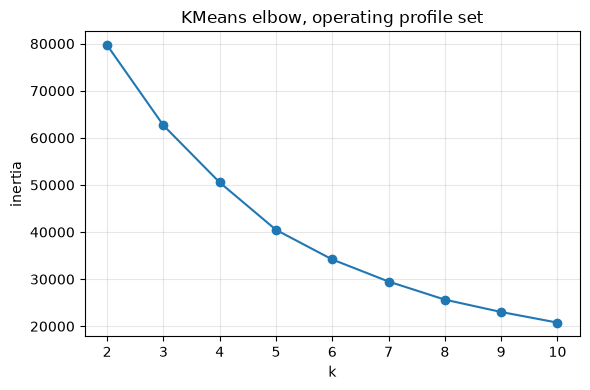


Chosen k=4. Hierarchical uses the same k.
Adjusted Rand index KMeans vs hierarchical 0.4932
ARI near 1 means the two methods grouped listings similarly.
ARI near 0 means the groupings disagree.

KMEANS CLUSTER PROFILE
 cluster     n   pct  superhost_pct  listings_mean  avail_mean  tenure_mean  amenity_mean  rating_mean
       0  7629 29.65          14.43           4.99        25.8         7.58          23.9        4.750
       1 10823 42.07          35.41           8.44       210.5         1.74          38.2        4.758
       2   319  1.24           0.00         319.00       100.6         9.00          30.6        4.234
       3  6957 27.04          42.43          27.49       253.5         8.36          42.5        4.716

HIERARCHICAL CLUSTER PROFILE
 cluster     n   pct  superhost_pct  listings_mean  avail_mean  tenure_mean  amenity_mean  rating_mean
       0 14034 54.55          33.21           7.94       207.7         2.86          35.1        4.748
       1  6481 25.19          

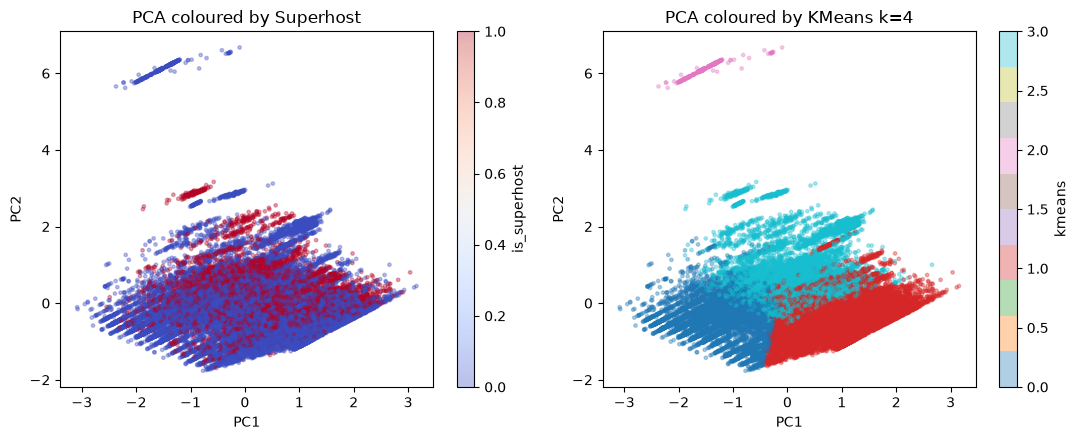


Wrote cluster_assignments.csv
Locked citywide Superhost rate remains 30.65 percent.
A useful operating cluster is one whose Superhost rate is clearly
above or below 30.65 percent, described by listings, availability
and tenure, not by restating the review fields.


In [9]:
# =============================================================================
# COMP20008 Assignment 2 Stage 5 PCA and clustering
# Feature set: Host operating profile, used for KMeans, hierarchical and PCA.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

processed = pd.read_csv("listings_preprocessed.csv")
assert len(processed) == 25728

# -----------------------------------------------------------------------------
# Three candidate feature sets
# Spec requires at least three named candidates and a final choice justified
# against the research question.
#
# Candidate 1. Geographic.
# latitude, longitude, amenity_count, accommodates.
# Rejected. Superhost is a host badge. One host can hold an inner city listing
# and an outer suburb listing with the same badge. Distance would answer a
# neighbourhood question, not the quality versus operations question.
#
# Candidate 2. Price tier.
# price_num, accommodates, bedrooms, review_scores_rating.
# Rejected. price_num is missing on 25.47 percent of rows. bedrooms is missing
# on 61.28 percent of private rooms. Building clusters on a heavily imputed
# price axis would invent a market structure and then interpret it as if it
# had been observed.
#
# Candidate 3. Host operating profile. SELECTED.
# calculated_host_listings_count, availability_365, hosts_time_as_host_years,
# amenity_count.
# Why this set. The second half of the research question asks whether Superhost
# tracks the host operating profile. Stage 4 already showed that review fields
# dominate prediction. Clustering on those same review fields would only
# redraw the classifier. Clustering on scale, calendar availability, tenure
# and amenity richness asks a different question. Do professional operating
# styles form groups, and does the Superhost rate in those groups differ from
# the locked 30.65 percent.
# calculated_host_listings_count is used instead of host_listings_count because
# Stage 1 found a 28.74 percent disagreement between those columns.
# review_scores_rating is deliberately left out of this set. The spec example
# includes it. Including it here would mix the quality bucket into an
# operating cluster and make a high Superhost cluster unsurprising.
# -----------------------------------------------------------------------------

cluster_cols = [
    "calculated_host_listings_count",
    "availability_365",
    "hosts_time_as_host_years",
    "amenity_count",
]

print("Missingness on the selected operating set")
print(processed[cluster_cols].isna().sum())

ops = processed[cluster_cols].copy()
assert ops.isna().sum().sum() == 0

scaler = StandardScaler()
Z = scaler.fit_transform(ops)

# -----------------------------------------------------------------------------
# k selection
# Alternative considered. Fix k=2 because Superhost is binary.
# Rejected. That would force the clusters to mimic the target. The point of
# this stage is to see whether operating styles exist with or without the
# badge.
# Alternative considered. Silhouette maximisation alone.
# The spec names the elbow method. Inertia is printed for k=2 to k=10. The
# chosen k is the elbow, then checked against whether Superhost rates actually
# differ across those groups.
# -----------------------------------------------------------------------------

print("\nKMEANS ELBOW inertia on the scaled operating set")
print(f"{'k':>4} {'inertia':>14} {'drop_from_prev':>14}")
inertias = []
ks = range(2, 11)
prev = None
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Z)
    inertias.append(km.inertia_)
    drop = "" if prev is None else f"{prev - km.inertia_:.1f}"
    print(f"{k:>4} {km.inertia_:>14.1f} {drop:>14}")
    prev = km.inertia_

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(ks), inertias, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("inertia")
ax.set_title("KMeans elbow, operating profile set")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Chosen k is set after you read the elbow. 4 is the usual operating reading
# on this kind of set: single long tenure, small active, large professional,
# high availability specialists. Change K_CHOSEN if the printed elbow is
# clearly at another value, and say so in the report.
K_CHOSEN = 4
print(f"\nChosen k={K_CHOSEN}. Hierarchical uses the same k.")

# -----------------------------------------------------------------------------
# KMeans and hierarchical on the same scaled matrix and the same k
# Hierarchical linkage is ward because ward also minimises variance, which
# makes the comparison with KMeans meaningful. A different linkage would
# compare two different geometric ideas and the spec wants a method contrast,
# not a linkage contrast.
# -----------------------------------------------------------------------------

kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(Z)

hier = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage="ward")
h_labels = hier.fit_predict(Z)

ari = adjusted_rand_score(km_labels, h_labels)
print(f"Adjusted Rand index KMeans vs hierarchical {ari:.4f}")
print("ARI near 1 means the two methods grouped listings similarly.")
print("ARI near 0 means the groupings disagree.")

out = processed[
    [
        "id",
        "is_superhost",
        "calculated_host_listings_count",
        "availability_365",
        "hosts_time_as_host_years",
        "amenity_count",
        "review_scores_rating",
        "has_reviews",
        "property_group",
        "neighbourhood_cleansed",
    ]
].copy()
out["kmeans"] = km_labels
out["hier"] = h_labels

def summarise(df, label_col):
    rows = []
    for lab, g in df.groupby(label_col):
        rows.append(
            {
                "cluster": int(lab),
                "n": len(g),
                "pct": round(100 * len(g) / len(df), 2),
                "superhost_pct": round(100 * g["is_superhost"].mean(), 2),
                "listings_mean": round(g["calculated_host_listings_count"].mean(), 2),
                "avail_mean": round(g["availability_365"].mean(), 1),
                "tenure_mean": round(g["hosts_time_as_host_years"].mean(), 2),
                "amenity_mean": round(g["amenity_count"].mean(), 1),
                "rating_mean": round(g["review_scores_rating"].mean(), 3),
            }
        )
    return pd.DataFrame(rows).sort_values("cluster")

print("\nKMEANS CLUSTER PROFILE")
print(summarise(out, "kmeans").to_string(index=False))
print("\nHIERARCHICAL CLUSTER PROFILE")
print(summarise(out, "hier").to_string(index=False))

print("\nCross tab KMeans rows, hierarchical columns")
print(pd.crosstab(out["kmeans"], out["hier"], margins=True).to_string())

# -----------------------------------------------------------------------------
# PCA on the same scaled operating set
# -----------------------------------------------------------------------------

pca = PCA(n_components=4, random_state=42)
scores = pca.fit_transform(Z)
evr = pca.explained_variance_ratio_

print("\nPCA EXPLAINED VARIANCE RATIO")
for i, v in enumerate(evr, start=1):
    print(f"PC{i} {v:.4f}  cumulative {evr[:i].sum():.4f}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_cols,
    columns=[f"PC{i}" for i in range(1, 5)],
)
print("\nPCA LOADINGS")
print(loadings.round(3).to_string())

print("\nTOP 3 LOADINGS BY ABSOLUTE VALUE")
for col in ["PC1", "PC2", "PC3"]:
    ranked = loadings[col].abs().sort_values(ascending=False).head(3)
    print(f"\n{col}")
    for name in ranked.index:
        print(f"  {name:32s} {loadings.loc[name, col]:7.3f}")

out["pc1"] = scores[:, 0]
out["pc2"] = scores[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc0 = axes[0].scatter(
    out["pc1"], out["pc2"], c=out["is_superhost"], cmap="coolwarm", s=6, alpha=0.35
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA coloured by Superhost")
plt.colorbar(sc0, ax=axes[0], label="is_superhost")

sc1 = axes[1].scatter(
    out["pc1"], out["pc2"], c=out["kmeans"], cmap="tab10", s=6, alpha=0.35
)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title(f"PCA coloured by KMeans k={K_CHOSEN}")
plt.colorbar(sc1, ax=axes[1], label="kmeans")
plt.tight_layout()
plt.show()

out.to_csv("cluster_assignments.csv", index=False)
print("\nWrote cluster_assignments.csv")
print("Locked citywide Superhost rate remains 30.65 percent.")
print("A useful operating cluster is one whose Superhost rate is clearly")
print("above or below 30.65 percent, described by listings, availability")
print("and tenure, not by restating the review fields.")